# Importing Libraries

In [1]:
#Importing necessary libraries

import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
import pandas as pd
import statsmodels.api as sm
import matplotlib
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

In [2]:
#data loading
df1 = pd.read_excel("Electricity_generation.xlsx")

In [3]:
df1.head()

,Year,Total all fuels,Coal,Oil,Natural Gas,Nuclear,Natural flow hydro,Wind and Solar,Coke and Breeze,Other Fuels
0,1920,3.68,3.67,0.02,NaN,NaN,0,\n,NaN,\n
1,1921,3.19,3.1,0.09,NaN,NaN,0,\n,NaN,\n
2,1922,3.21,3.17,0.04,NaN,NaN,0,\n,NaN,\n
3,1923,3.62,3.57,0.05,NaN,NaN,0,\n,NaN,\n
4,1924,3.9,3.85,0.05,NaN,NaN,0,\n,NaN,\n


In [4]:
#setting year as index
df1.set_index('Year')

,Total all fuels,Coal,Oil,Natural Gas,Nuclear,Natural flow hydro,Wind and Solar,Coke and Breeze,Other Fuels
Year,,,,,,,,,
1920,3.68,3.67,0.02,NaN,NaN,0,\n,NaN,\n
1921,3.19,3.1,0.09,NaN,NaN,0,\n,NaN,\n
1922,3.21,3.17,0.04,NaN,NaN,0,\n,NaN,\n
1923,3.62,3.57,0.05,NaN,NaN,0,\n,NaN,\n
1924,3.9,3.85,0.05,NaN,NaN,0,\n,NaN,\n
...,...,...,...,...,...,...,...,...,...
2017,61.71,5.55,0.54,24.60,15.12,0.51,5.25,NaN,10.13
2018,59.88,4.24,0.49,23.51,14.06,0.47,5.98,NaN,11.13
2019,56.19,1.85,0.39,23.45,12.09,0.51,6.56,NaN,11.35


In [5]:
#replacing missing values with zero
df1.replace(to_replace='\n',value=0,inplace=True)
df1.fillna(0)

,Year,Total all fuels,Coal,Oil,Natural Gas,Nuclear,Natural flow hydro,Wind and Solar,Coke and Breeze,Other Fuels
0,1920,3.68,3.67,0.02,0,0,0,0,0,0
1,1921,3.19,3.1,0.09,0,0,0,0,0,0
2,1922,3.21,3.17,0.04,0,0,0,0,0,0
3,1923,3.62,3.57,0.05,0,0,0,0,0,0
4,1924,3.9,3.85,0.05,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
98,2017,61.71,5.55,0.54,24.60,15.12,0.51,5.25,0,10.13
99,2018,59.88,4.24,0.49,23.51,14.06,0.47,5.98,0,11.13
100,2019,56.19,1.85,0.39,23.45,12.09,0.51,6.56,0,11.35
101,2020,52.38,1.47,0.36,19.98,10.72,0.59,7.61,0,11.65


In [6]:
df1.dtypes

Year                   int64
Total all fuels       object
Coal                  object
Oil                   object
Natural Gas           object
Nuclear               object
Natural flow hydro    object
Wind and Solar        object
Coke and Breeze       object
Other Fuels           object
dtype: object

In [7]:
#extracting necessary features
df = df1[['Year','Total all fuels']].copy()

In [8]:
df.head()

,Year,Total all fuels
0,1920,3.68
1,1921,3.19
2,1922,3.21
3,1923,3.62
4,1924,3.9


In [9]:
#changing datatype of the column
df['Total all fuel'] = df['Total all fuels'].astype(float)

In [10]:
df = df.groupby('Year')['Total all fuel'].sum().reset_index()

In [11]:
df.head()

,Year,Total all fuel
0,1920,3.68
1,1921,3.19
2,1922,3.21
3,1923,3.62
4,1924,3.90


# Exploratory data analysis

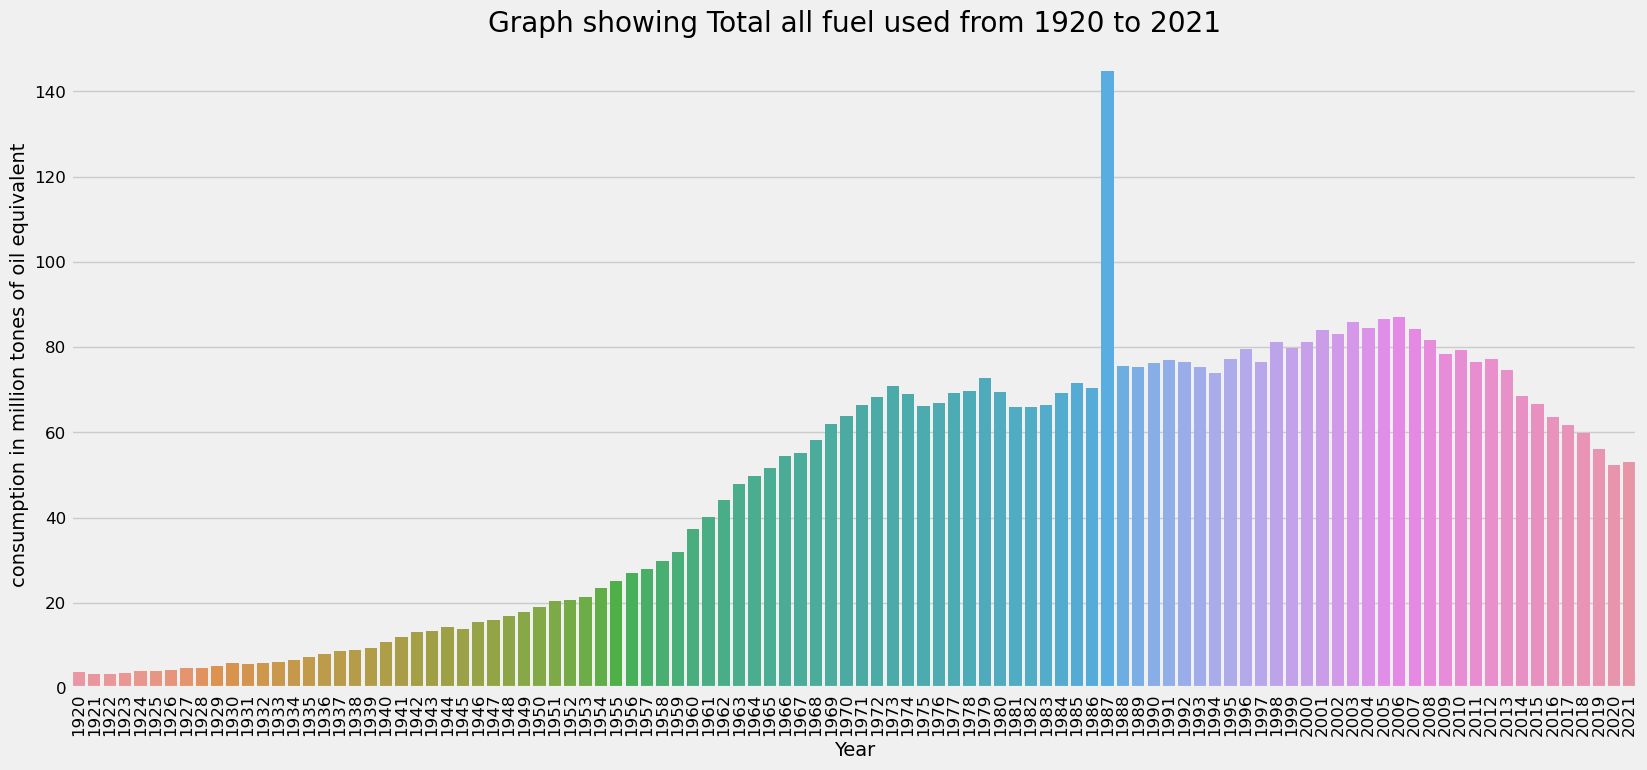

In [12]:
#plotting bar graph showing year and corresponding fuel consumption
plt.figure(figsize=(18,8))
sns.barplot(x=df['Year'],y=df['Total all fuel'])
plt.xticks(rotation=90)
plt.title('Graph showing Total all fuel used from 1920 to 2021')
plt.ylabel('consumption in million tones of oil equivalent')
plt.show()

From the graph it is clear that the consumption of total fuel for generation of electricity has increased till the begining of 21st Centuary and now it follows a downward trend.

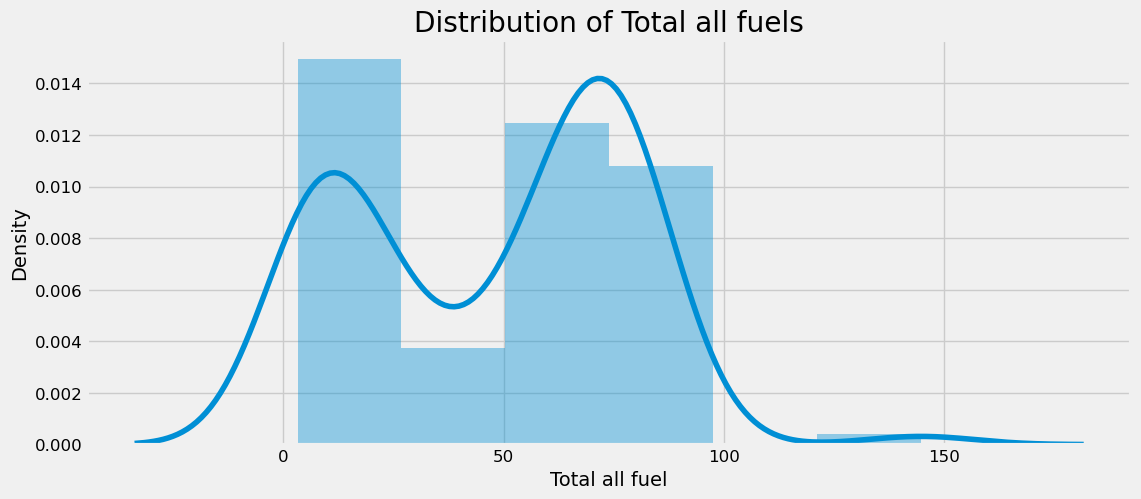

In [13]:
#plotting distribution graph of total fuel consumed
plt.figure(figsize=(12,5))
plt.title("Distribution of Total all fuels")
ax = sns.distplot(df['Total all fuel'])
plt.show()

The above graph shows that the consumption of total fuel in a range of 50 to 100 Mtoe is higher 

In [14]:
df.head()

,Year,Total all fuel
0,1920,3.68
1,1921,3.19
2,1922,3.21
3,1923,3.62
4,1924,3.90


In [15]:
#changing year to datetime
df.index = pd.to_datetime(df["Year"],format = '%Y')
df

,Year,Total all fuel
Year,,
1920-01-01,1920,3.68
1921-01-01,1921,3.19
1922-01-01,1922,3.21
1923-01-01,1923,3.62
1924-01-01,1924,3.90
...,...,...
2017-01-01,2017,61.71
2018-01-01,2018,59.88
2019-01-01,2019,56.19


In [16]:
y = df['Total all fuel']

# Time Series Analysis

## Plotting yearly variation of the dataset

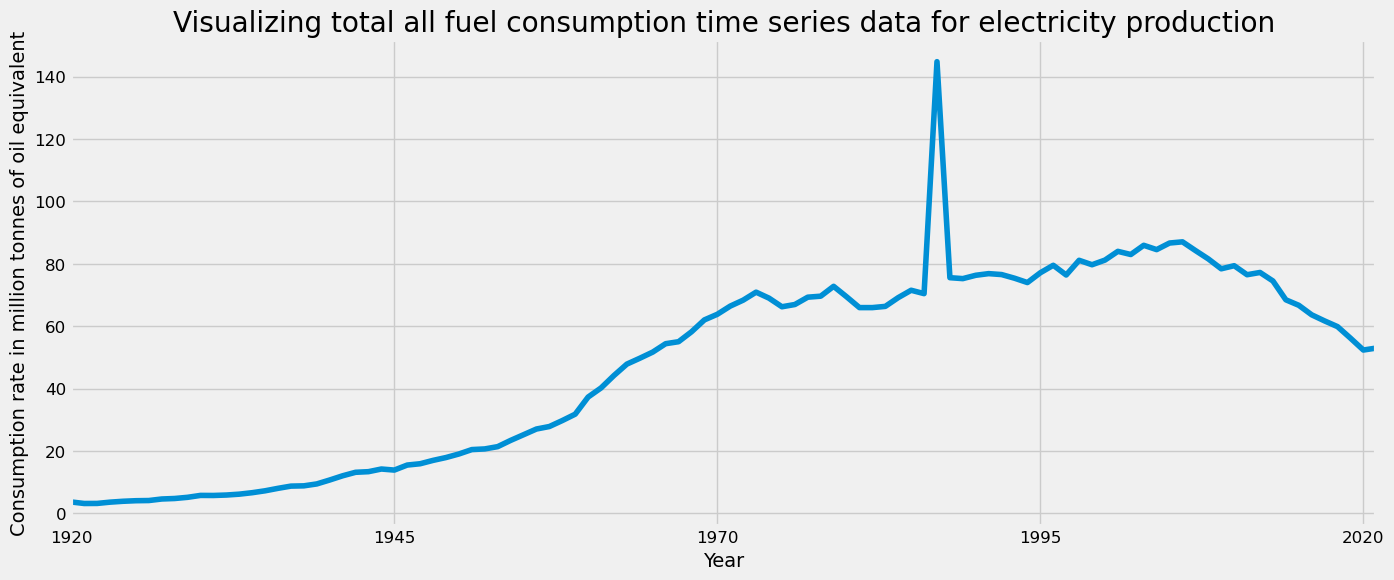

In [17]:
y.plot(figsize=(15, 6))
plt.ylabel('Consumption rate in million tonnes of oil equivalent')
plt.title('Visualizing total all fuel consumption time series data for electricity production')
plt.show()

## Trend Analysis

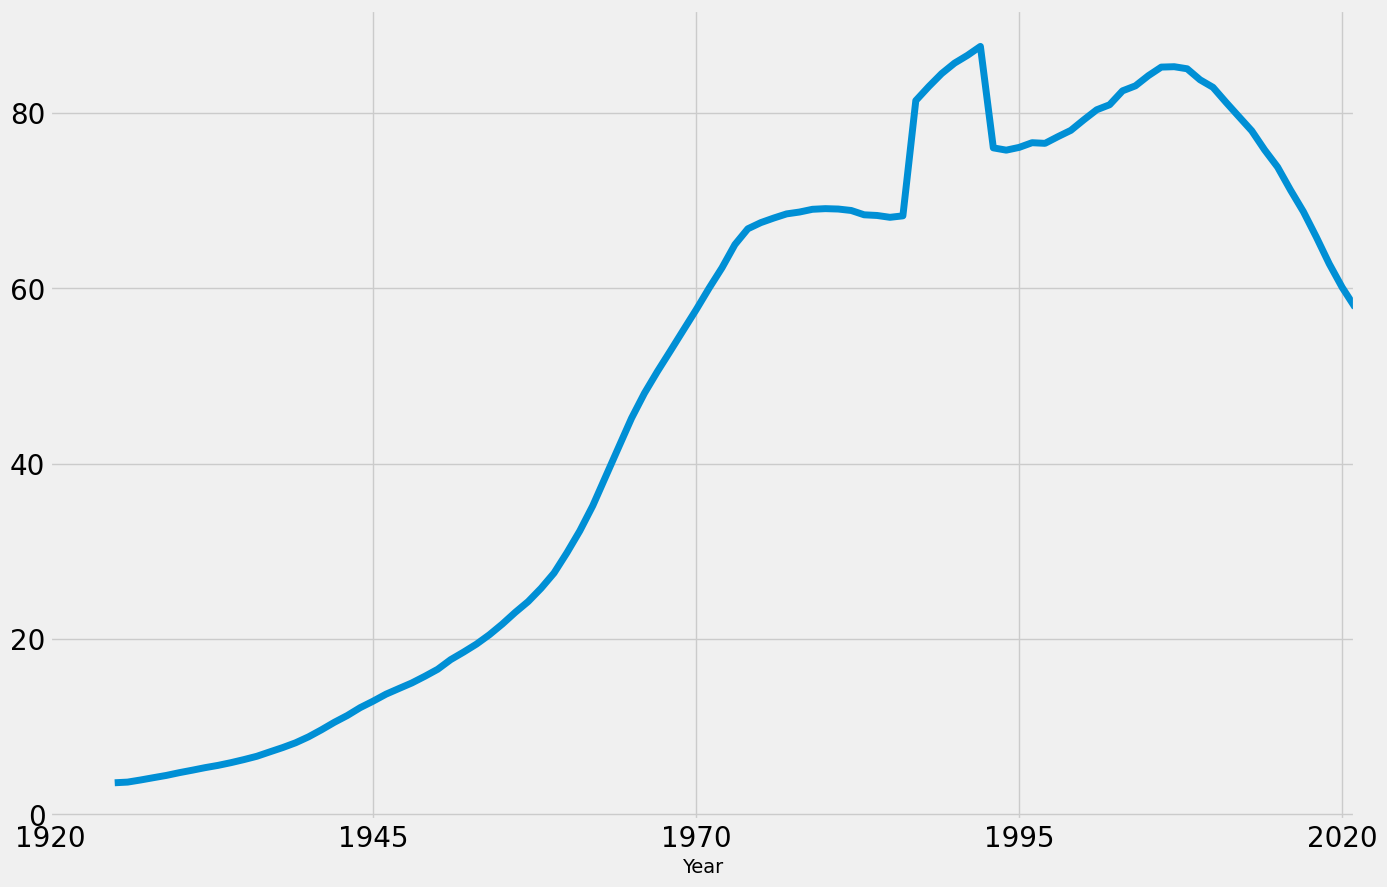

In [18]:
y.rolling(6).mean().plot(figsize=(15,10), linewidth=5, fontsize=20)
plt.show()

## Seasonability Analysis

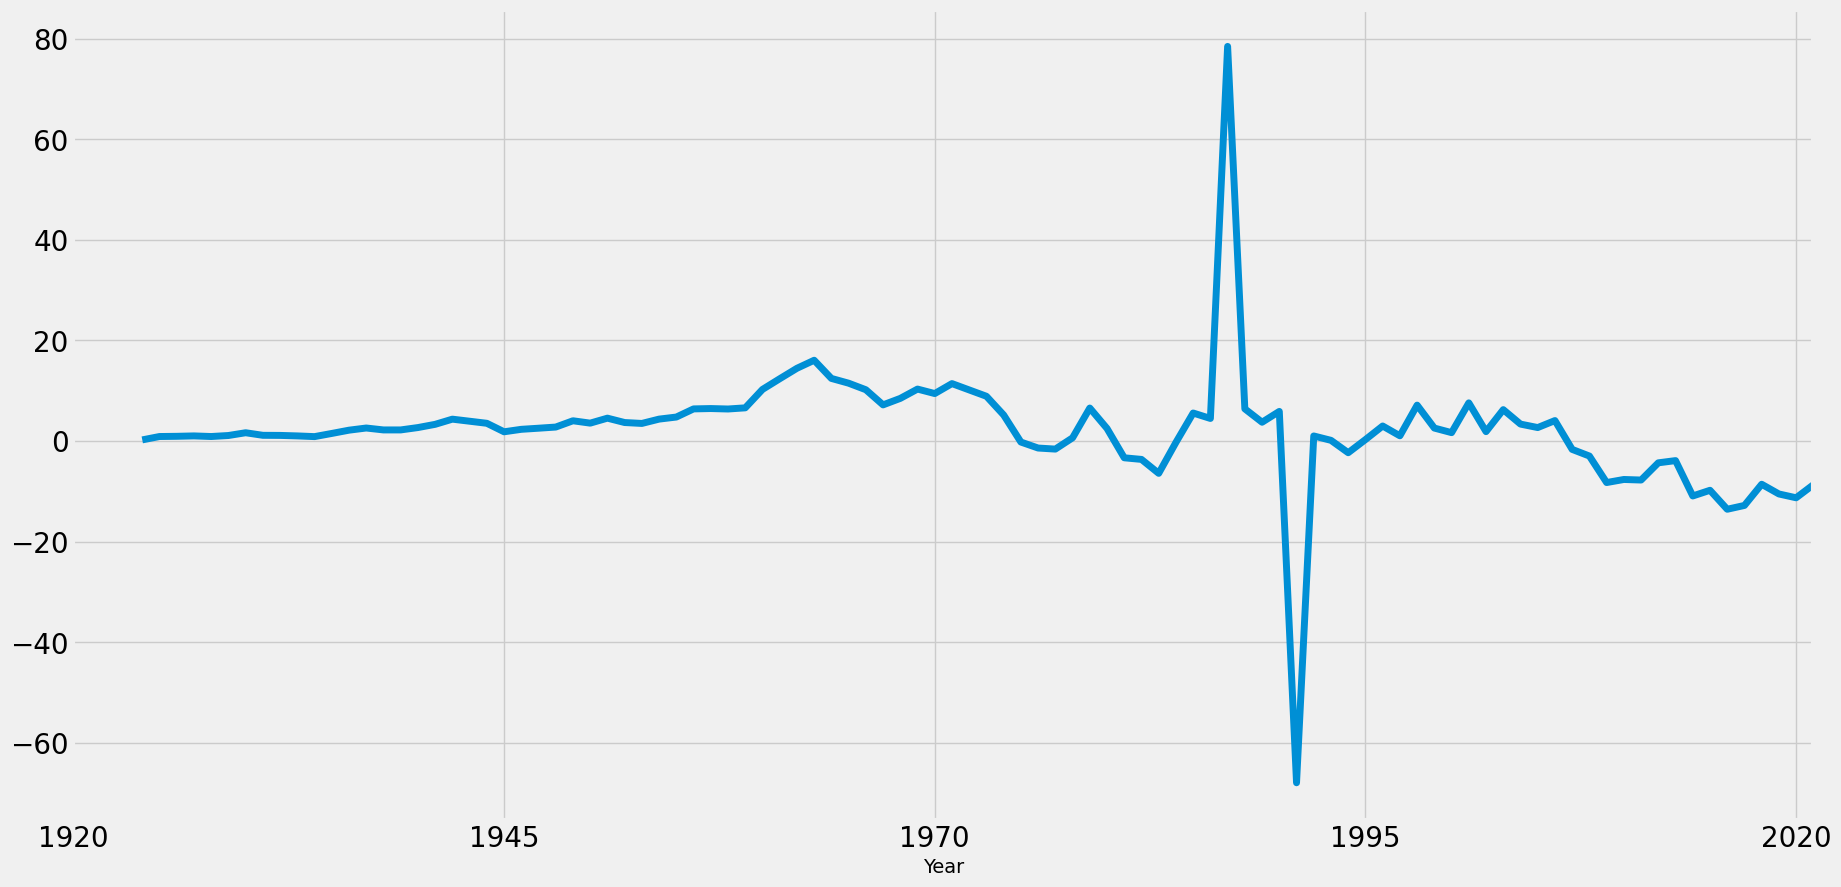

In [19]:
y.diff(periods=4).plot(figsize=(20,10), linewidth=5, fontsize=20)
plt.show()

There is no particular seasonal trend in this dataset because the energy consumption doesnot depends on seasons

## Autocorrelation

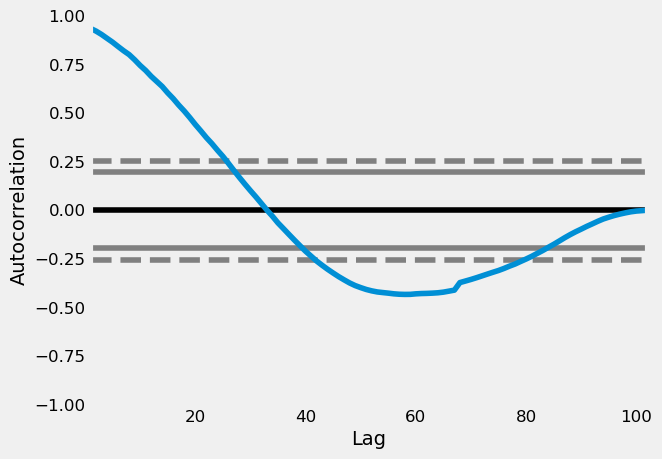

In [20]:
pd.plotting.autocorrelation_plot(y)
plt.show()

## Lag plot

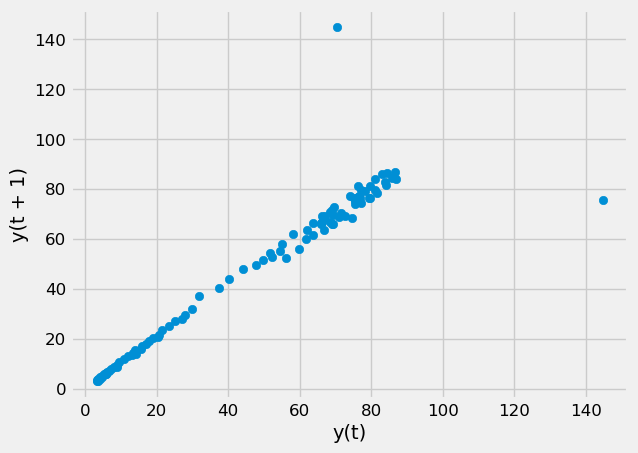

In [21]:
pd.plotting.lag_plot(y)
plt.show()

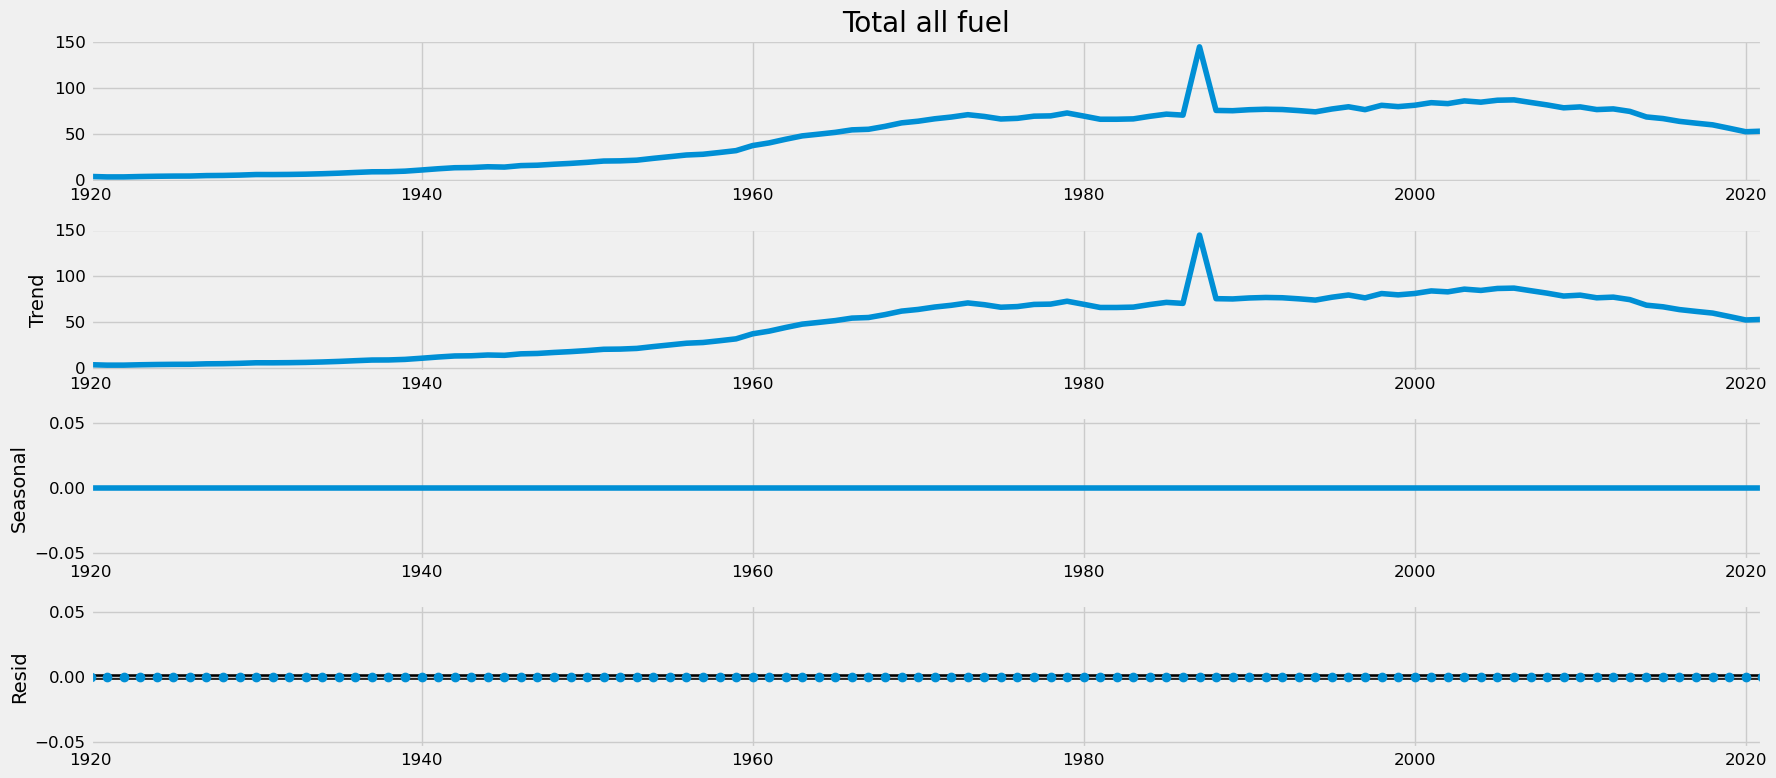

In [22]:
#plotting trend,seasonability and noise
from pylab import rcParams
rcParams['figure.figsize'] = 18, 8

decomposition = sm.tsa.seasonal_decompose(y, model='additive')
fig = decomposition.plot()
plt.show()

# Model Building using ARIMA model

In [23]:
#Setting a range to find the optimum paramters
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [24]:
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(y,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)

            results = mod.fit()

            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
        except:
            continue

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            1     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.41056D+00    |proj g|=  1.71754D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    1      1      3      1     0     0   3.961D-08   5.411D+00
  F =   5.4105312019110325     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
ARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:1105.7483651898506
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variabl

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.29816D+00    |proj g|=  3.77210D+00

At iterate    5    f=  3.91147D+00    |proj g|=  1.03764D+00

At iterate   10    f=  3.81555D+00    |proj g|=  5.69978D-03

At iterate   15    f=  3.81165D+00    |proj g|=  2.59233D-02

At iterate   20    f=  3.81125D+00    |proj g|=  5.07239D-06

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     20     23      1     0     0   5.072D-06   3.811D+00
  F =   3.8112538647549017     

CONVERG

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.



At iterate    5    f=  4.40890D+00    |proj g|=  1.15480D-02

At iterate   10    f=  4.18304D+00    |proj g|=  1.09064D+00

At iterate   15    f=  4.07738D+00    |proj g|=  4.87874D-02

At iterate   20    f=  4.07597D+00    |proj g|=  9.33129D-06

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     20     24      1     0     0   9.331D-06   4.076D+00
  F =   4.0759716765660290     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
ARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:837.4982220194698
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0

...

ARIMA(1, 1, 0)x(1, 1, 1, 12)12 - AIC:591.1787911150984
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.50165D+00    |proj g|=  3.93379D-02

At iterate    5    f=  3.50048D+00    |proj g|=  3.94865D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      9     12      1     0     0   2.020D-06   3.500D+00
  F =   3.5004574872598266     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
ARIMA(1, 1, 1)x(0, 0, 0, 12)12 - AIC:720.0933274010047
RUNNING THE L-BFGS-B C

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.


ARIMA(1, 1, 1)x(0, 1, 1, 12)12 - AIC:576.9691956003215
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.16618D+00    |proj g|=  4.65356D-02

At iterate    5    f=  3.16374D+00    |proj g|=  1.16986D-02

At iterate   10    f=  3.16214D+00    |proj g|=  7.17693D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     12     14      1     0     0   6.353D-06   3.162D+00
  F =   3.1621360986061862     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
ARIMA(1, 1, 1)x

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.



At iterate    5    f=  2.84061D+00    |proj g|=  2.70556D-02

At iterate   10    f=  2.80093D+00    |proj g|=  1.28594D-02

At iterate   15    f=  2.80050D+00    |proj g|=  6.02351D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     16     19      1     0     0   1.289D-06   2.801D+00
  F =   2.8005047960355665     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
ARIMA(1, 1, 1)x(1, 1, 1, 12)12 - AIC:581.3029783912556


In [25]:
#Model fitting
mod = sm.tsa.statespace.SARIMAX(y,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit()

print(results.summary().tables[1])

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.92520D+00    |proj g|=  1.99089D-02

At iterate    5    f=  2.92107D+00    |proj g|=  2.39187D-02

At iterate   10    f=  2.91602D+00    |proj g|=  1.85233D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     11     14      1     0     0   9.921D-07   2.916D+00
  F =   2.9160209303510229     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                 coef    std err          z      P>|z|      [0.025    

 This problem is unconstrained.


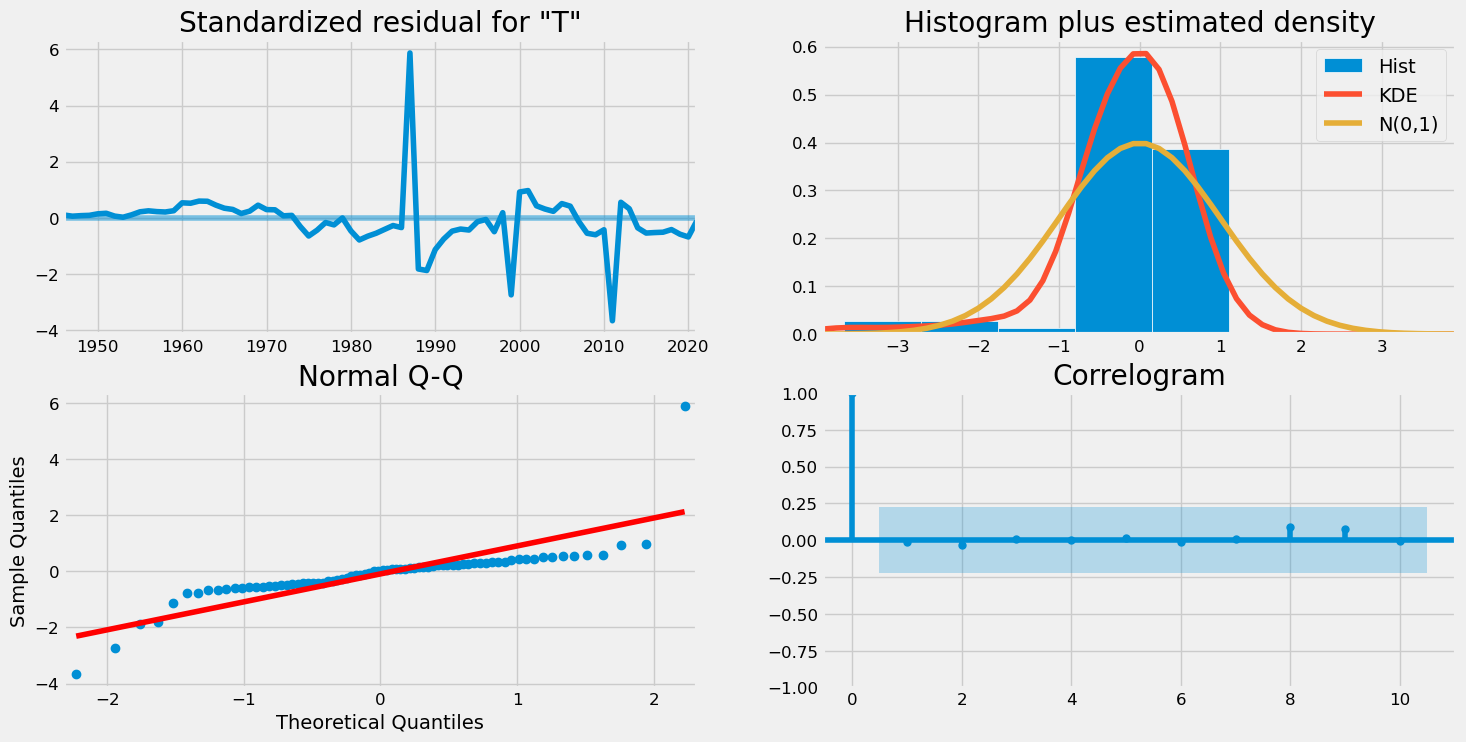

In [26]:
#Diagnostic checks
results.plot_diagnostics(figsize=(16, 8))
plt.show()

# Validating Forecasts

In [27]:
#comparing predicted and expected values
size = int(len(df) - 30)
train, test = y[0:size], y[size:len(df)]

print('\t ARIMA MODEL : In- Sample Forecasting \n')

history = [x for x in train]
predictions = []

for t in range(len(test)):
    
    model = sm.tsa.arima.ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(float(yhat))
    
    obs = test[t]
    history.append(obs)
    
    print('predicted = %f, expected = %f' % (yhat, obs))

	 ARIMA MODEL : In- Sample Forecasting 

predicted = 79.099663, expected = 76.570000
predicted = 77.928225, expected = 75.400000
predicted = 76.856739, expected = 74.010000
predicted = 75.659028, expected = 77.150000
predicted = 76.007041, expected = 79.550000
predicted = 77.411464, expected = 76.430000
predicted = 77.299518, expected = 81.140000
predicted = 78.574640, expected = 79.720000
predicted = 79.277744, expected = 81.210000
predicted = 80.021813, expected = 84.010000
predicted = 81.593318, expected = 83.000000
predicted = 82.379324, expected = 85.950000
predicted = 83.743595, expected = 84.570000
predicted = 84.300785, expected = 86.680000
predicted = 85.194231, expected = 87.060000
predicted = 86.046299, expected = 84.280000
predicted = 85.526785, expected = 81.580000
predicted = 83.952032, expected = 78.420000
predicted = 81.662600, expected = 79.410000
predicted = 80.466810, expected = 76.520000
predicted = 78.887019, expected = 77.240000
predicted = 78.003344, expected = 7

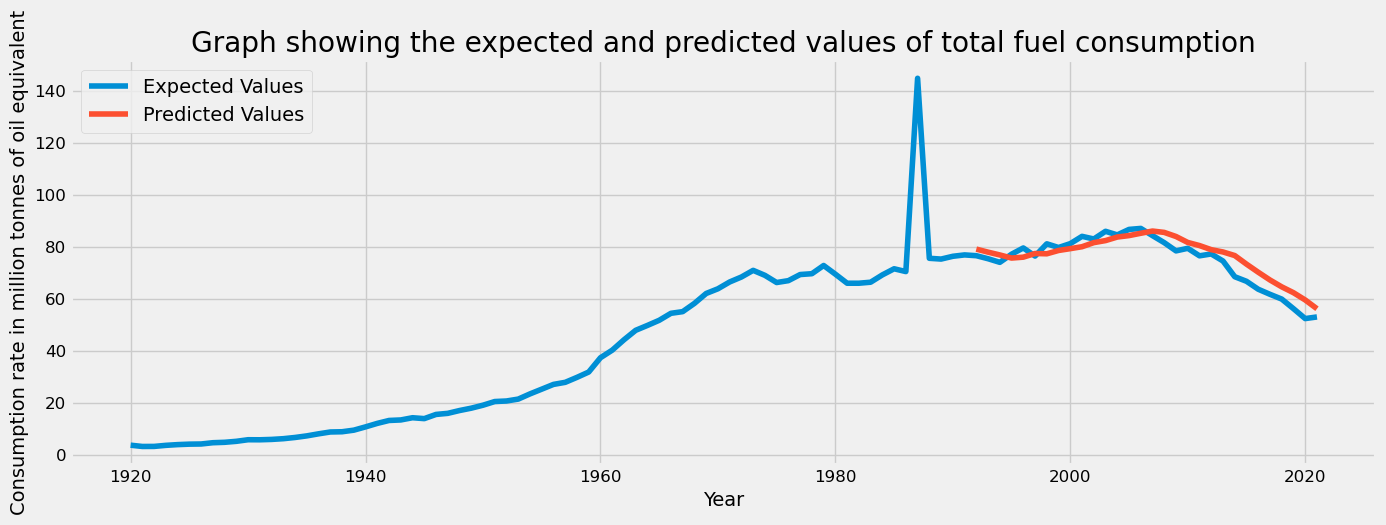

In [28]:
#plotting predicted and expected values
predictions_series = pd.Series(predictions, index = test.index)
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (15,5))

plt.subplot(1,1,1)
plt.xlabel('Year')
plt.ylabel('Consumption rate in million tonnes of oil equivalent')
plt.title('Graph showing the expected and predicted values of total fuel consumption')
plt.plot(y,label = 'Expected Values')
plt.plot(predictions_series,label = 'Predicted Values');
plt.legend(loc="upper left")
plt.show()

In [29]:
#finding mean square error
print(mean_squared_error(test,predictions))

16.196340263294154


In [30]:
#finding root mean square
error = np.sqrt(mean_squared_error(test,predictions))
print('Test RMSE: %.4f' % error)

Test RMSE: 4.0245


# Visualizing future predictions

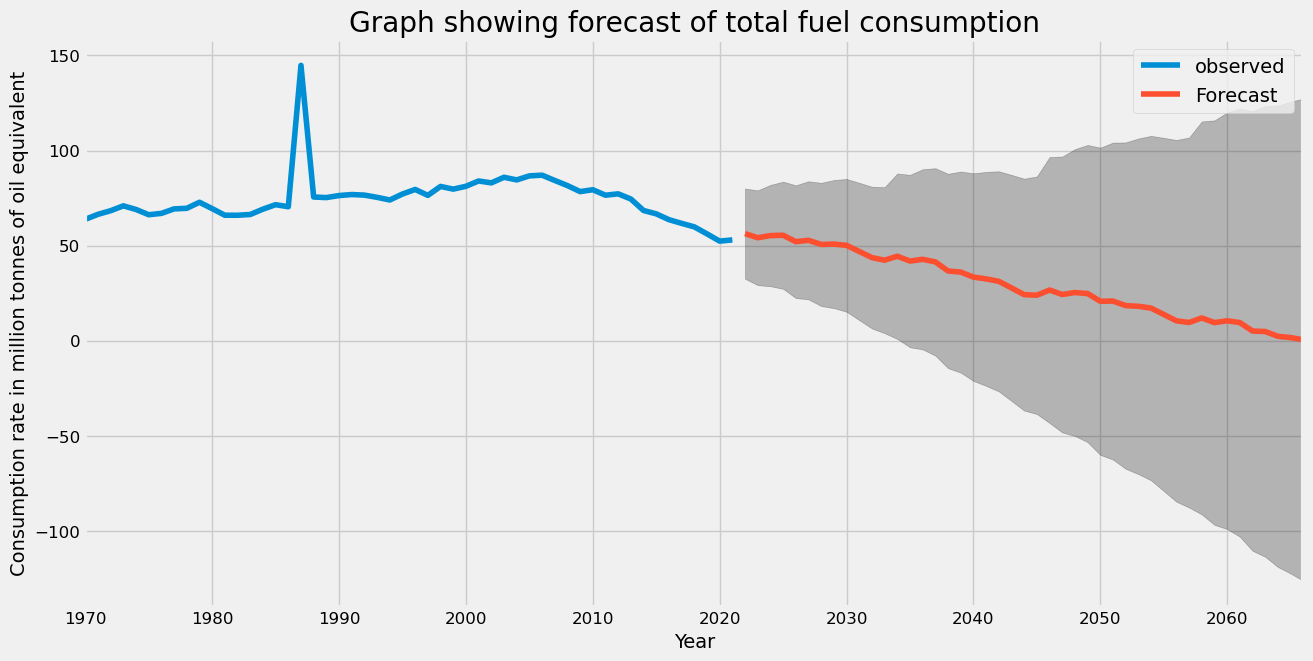

In [31]:
#plotting forecasts
pred_uc = results.get_forecast(steps=45)
pred_ci = pred_uc.conf_int()

ax = y['1970':].plot(label='observed', figsize=(14, 7))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Year')
ax.set_ylabel('Consumption rate in million tonnes of oil equivalent')
ax.set_title("Graph showing forecast of total fuel consumption")

plt.legend()
plt.show()

# Saving the Predicted Values

In [32]:
predicted_values=pred_uc.predicted_mean

In [33]:
predicted_values = predicted_values.to_frame()

In [34]:
predicted_values.head()

,predicted_mean
2022-01-01,56.309934
2023-01-01,54.155842
2024-01-01,55.285583
2025-01-01,55.472453
2026-01-01,52.081753


In [35]:
#Saving the dataset
predicted_values.to_csv("/Users/nikhilbaby/Desktop/predicted.csv.csv")